In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#use to load dataset
from datasets import load_dataset

In [ ]:
emotion_dataset=load_dataset('dair-ai/emotion')

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

In [ ]:
label_name=emotion_dataset['train'].features['label'].names

In [ ]:
df_train=pd.DataFrame({
    'text':train_text,
    'label':[label_name[i] for i in train_label]
})
df_test=pd.DataFrame({
    'text':test_text,
    'label':[label_name[i] for i in test_label]
})

In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
#eda

In [ ]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

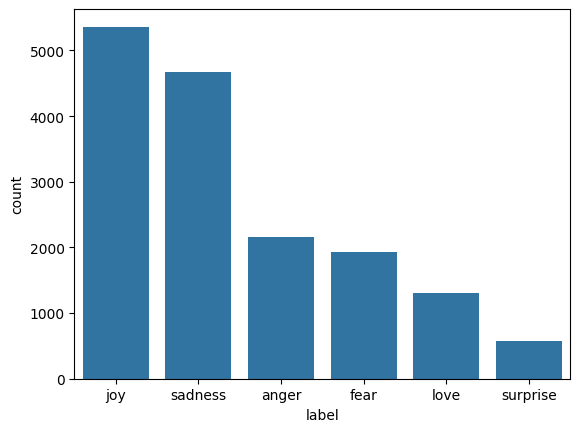

In [ ]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000
tokenizer=Tokenizer(num_words=max_words,oov_token='<unk>')

In [ ]:
tokenizer.fit_on_texts(df_train['text'])

In [ ]:
train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

In [ ]:
padded_train_seq=pad_sequences(train_sequence,maxlen=50,truncating='post',padding='post')
padding_test_seq=pad_sequences(test_sequence,maxlen=50,truncating='post',padding='post')

In [ ]:
train_labels=np.array(train_label)
train_labels
test_labels=np.array(test_label)

In [ ]:
num_classes=len(label_name)
num_classes

6

In [ ]:
print(f"vocab_size: {len(tokenizer.word_index)}")
print(f"max sentence length: {padded_train_seq.shape[1]}")

vocab_size: 15213
max sentence length: 50


In [ ]:
from sklearn.utils import class_weight
class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

In [ ]:
dict(enumerate(class_weights))

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
#model training

In [ ]:
# model 1: Rnn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,Dropout,LSTM,GRU

In [ ]:
rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_seq,
    train_labels,
    validation_data=(padding_test_seq,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=dict(enumerate(class_weights)),
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.1602 - loss: 2.0301 - val_accuracy: 0.0575 - val_loss: 1.8612
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1473 - loss: 1.8987 - val_accuracy: 0.2625 - val_loss: 1.7205
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1219 - loss: 1.8316 - val_accuracy: 0.1340 - val_loss: 1.7804
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1299 - loss: 1.8111 - val_accuracy: 0.0815 - val_loss: 1.8064
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1266 - loss: 1.8024 - val_accuracy: 0.3475 - val_loss: 1.7791


In [ ]:
rnn_loss,rnn_accuracy=rnn_model.evaluate(padding_test_seq,test_labels)
print(f"rnn Loss: {rnn_loss}")
print(f"rnn Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2625 - loss: 1.7205
rnn Loss: 1.7204853296279907
rnn Accuracy: 0.26249998807907104


In [ ]:
#LSTM

In [ ]:
lstm_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
lstm_model.fit(
    padded_train_seq,
    train_labels,
    validation_data=(padding_test_seq,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=dict(enumerate(class_weights)),
    callbacks=[early_stopping]
)
lstm_loss,lstm_accuracy=lstm_model.evaluate(padding_test_seq,test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.1388 - loss: 1.7946 - val_accuracy: 0.2915 - val_loss: 1.7568
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1582 - loss: 1.7942 - val_accuracy: 0.3490 - val_loss: 1.7591
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.1698 - loss: 1.7939 - val_accuracy: 0.2870 - val_loss: 1.7880
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2915 - loss: 1.7568
LSTM Loss: 1.756809115409851
LSTM Accuracy: 0.2915000021457672


In [ ]:
gru_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
gru_model.fit(
      padded_train_seq,
      train_labels,
      validation_data=(padding_test_seq,test_labels),
      epochs=20,
      batch_size=32,
      class_weight=dict(enumerate(class_weights)),
      callbacks=[early_stopping]
)
gru_loss,gru_accuracy=gru_model.evaluate(padding_test_seq,test_labels)
print(f"gru Loss: {gru_loss}")
print(f"gru Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1659 - loss: 1.7967 - val_accuracy: 0.0330 - val_loss: 1.8136
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1539 - loss: 1.7951 - val_accuracy: 0.1375 - val_loss: 1.8027
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1564 - loss: 1.7941 - val_accuracy: 0.0800 - val_loss: 1.8141
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0330 - loss: 1.8136
gru Loss: 1.8136307001113892
gru Accuracy: 0.032999999821186066


In [ ]:
result_df=pd.DataFrame({
    'model':['rnn','lstm','gru'],
    'loss':[rnn_loss,lstm_loss,gru_loss],
    'accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
})
#

In [ ]:
result_df

,model,loss,accuracy
0,rnn,1.720485,0.2625
1,lstm,1.756809,0.2915
2,gru,1.813631,0.0330


In [ ]:
from tensorflow.keras.layers import Bidirectional
BIGRU=Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
BIGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
BIGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BIGRU.fit(padded_train_seq,
    train_labels,
    validation_data=(padding_test_seq,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=dict(enumerate(class_weights)),
    callbacks=[early_stopping])

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5959 - loss: 0.9972 - val_accuracy: 0.8515 - val_loss: 0.4809
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9169 - loss: 0.2421 - val_accuracy: 0.9150 - val_loss: 0.2566
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9443 - loss: 0.1527 - val_accuracy: 0.9170 - val_loss: 0.2886
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9555 - loss: 0.1163 - val_accuracy: 0.9125 - val_loss: 0.2779
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9649 - loss: 0.0974 - val_accuracy: 0.9160 - val_loss: 0.2781


In [ ]:
BiGru_loss,BiGru_accuracy=BIGRU.evaluate(padding_test_seq,test_labels)
print(f"BiGru Loss: {BiGru_loss}")
print(f"BiGru Accuracy: {BiGru_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9150 - loss: 0.2566
BiGru Loss: 0.25660204887390137
BiGru Accuracy: 0.9150000214576721


In [ ]:
#evaluation and analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


<Axes: >

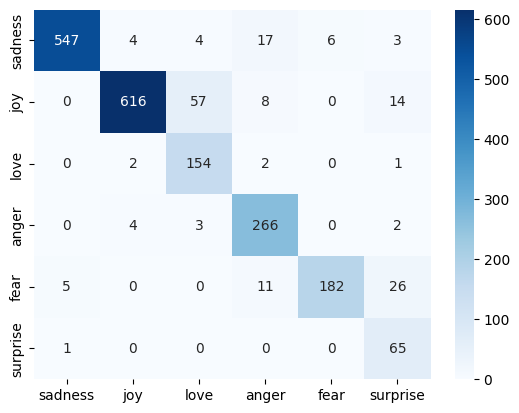

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
BiGRU_predictions=BIGRU.predict(padding_test_seq)
BiGRU_predictions=np.argmax(BiGRU_predictions,axis=1)

sns.heatmap(confusion_matrix(test_labels,BiGRU_predictions),annot=True,fmt='d',cmap='Blues',xticklabels=label_name,yticklabels=label_name)

In [ ]:
sample_texts=[
    "i cant beleive how happy i am right now",
    "i feel so alone and hopeless today.",
    "i am furious that they cancelled the trip",
    "i was shocked and completely suprised by this gift.",
    "i feel terrified when walking down dark alleways alone"
]
sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences,maxlen=50,truncating='post',padding='post')
sample_predictions=BIGRU.predict(sample_padded_sequences)
sample_predictions=np.argmax(sample_predictions,axis=1)
sample_predictions
for i in range(len(sample_texts)):
  print(f"Texts: {sample_texts[i]}")
  print(f"Prediction: {label_name[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Texts: i cant beleive how happy i am right now
Prediction: anger
Texts: i feel so alone and hopeless today.
Prediction: sadness
Texts: i am furious that they cancelled the trip
Prediction: anger
Texts: i was shocked and completely suprised by this gift.
Prediction: surprise
Texts: i feel terrified when walking down dark alleways alone
Prediction: fear


In [43]:
import os
import pickle
model_dir='Artifacts'
os.makedirs(model_dir,exist_ok=True)
#save bigru
BIGRU.save(os.path.join(model_dir,'BIGRU_Modle.keras'))
#save tokenizer
with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as f:
  pickle.dump(tokenizer,f)